## Plots of rescaled limits

This notebook is used for plotting rescaled limits i.e. converting axial-vector to vector $Z'$ mediators

In [ ]:
# import useful packages
import mplhep as hep
import matplotlib.pyplot as plt
import json
import numpy as np
import matplotlib as mpl

In [2]:
# this defines what inputs to use
inputs = [
    {
        "label": "ATLAS Run 2 Dijet TLA" + "\n" + "PRD 112, 092015 (2025)\n" + r"$\sqrt{s} = 13$ TeV, 15-132 fb$^{-1}$",
        "observed_rescaled": ["../outputs/TLADijetRun2_J50_observed_rescaledVector.json", "../outputs/TLADijetRun2_J100_observed_rescaledVector.json"],
        "expected_rescaled": ["../outputs/TLADijetRun2_J50_expected_rescaledVector.json", "../outputs/TLADijetRun2_J100_expected_rescaledVector.json"],
        "observed_original": ["../inputs/TLADijetRun2_J50_observed_limit.json", "../inputs/TLADijetRun2_J100_observed_limit.json"],
        "expected_original": ["../inputs/TLADijetRun2_J50_expected_limit.json", "../inputs/TLADijetRun2_J100_expected_limit.json"],
    },
]

benchmark_name = "minimal_dark_photon"

In [3]:
# retrieve the limit information from the original input files
original_limit_info = dict()
with open("../inputs/TLADijetRun2_limit_params.json", "r") as f:
    original_limit_info = json.load(f)

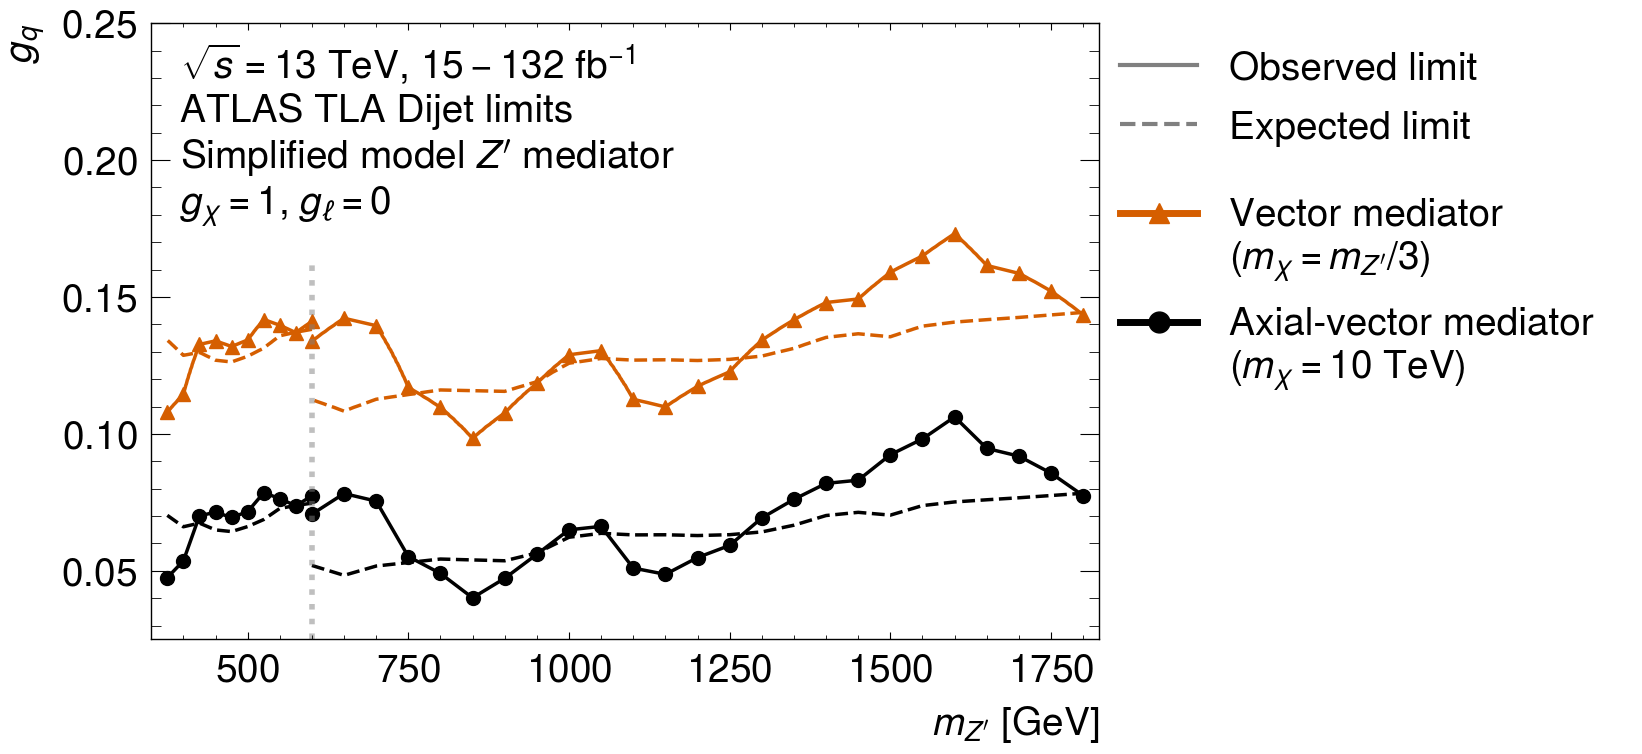

In [41]:
# now make a plot of the rescaled limits
hep.style.use("ATLAS")
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlabel(r"$m_{Z'}$ [GeV]", fontsize=28)
ax.set_ylabel(r"$g_q$", fontsize=28)
ax.tick_params(axis="both", which="both", labelsize=28, pad=10)

# load the original limits and plot them
expected_limit = dict()
observed_limit = dict()
signal_region_points = list()
for orig_expected, orig_observed in zip(inputs[0]["expected_original"], inputs[0]["observed_original"]):
    with open(orig_expected, "r") as f:
        expected_limit = json.load(f)
    with open(orig_observed, "r") as f:
        observed_limit = json.load(f)
    ax.plot(
        expected_limit["mmed"],
        expected_limit["gq_limit"],
        color="black",
        linestyle="--",
        lw=2.5,
    )
    ax.plot(
        observed_limit["mmed"],
        observed_limit["gq_limit"],
        color="black",
        linestyle="-",
        marker="o",
        markersize=10,
        lw=2.5,
    )
    signal_region_points.append(
        observed_limit["mmed"]
    )

# now do the same for the rescaled limits
region_counter = 0
for rescaled_expected, rescaled_observed in zip(inputs[0]["expected_rescaled"], inputs[0]["observed_rescaled"]):
    with open(rescaled_expected, "r") as f:
        expected_limit = json.load(f)
    with open(rescaled_observed, "r") as f:
        observed_limit = json.load(f)
    for x_contour, y_contour in zip(expected_limit["mmed_contours"], expected_limit["gq_contours"]):
        ax.plot(
            x_contour,
            y_contour,
            color="C0",
            linestyle="--",
            lw=2.5,
        )
    for x_contour, y_contour in zip(observed_limit["mmed_contours"], observed_limit["gq_contours"]):
        ax.plot(
            x_contour,
            y_contour,
            color="C0",
            linestyle="-",
            # marker="^",
            # markersize=10,
            lw=2.5,
        )
        # downsample in x to make the plot look nicer with markers
        mass_mask = np.full_like(x_contour, False, dtype=bool)
        for mass in signal_region_points[region_counter]:
            mass_mask = mass_mask | np.isclose(x_contour, mass)
        ax.plot(
            np.array(x_contour)[mass_mask],
            np.array(y_contour)[mass_mask],
            color="C0", 
            linestyle="none",
            marker="^",
            markersize=10,
        )

    region_counter += 1

ax.set_xlim(350, 1825)

# add a legend and some text
leg = ax.legend(
    handles=[
        mpl.lines.Line2D([], [], color="gray", linestyle="-", label="Observed limit", lw=3),
        mpl.lines.Line2D([], [], color="gray", linestyle="--", label="Expected limit", lw=3),
        mpl.lines.Line2D([], [], color="C0", linestyle="-", label="Vector mediator\n" + r"($m_{\chi} = m_{Z'}/3$)", lw=5, marker="^", markersize=15),
        mpl.lines.Line2D([], [], color="k", linestyle="-", label="Axial-vector mediator\n" + r"($m_{\chi} = 10$ TeV)", lw=5, marker="o", markersize=15),
    ],
    loc="upper left",
    fontsize=28,
    bbox_to_anchor=(0.96, 1.05),
    labelspacing=0.6,
)
for text in leg.get_texts()[2:]:
    text.set_y(text.get_position()[1] - 27)

_ = ax.text(
    0.03, 0.97,
    r"$\sqrt{s} = 13$ TeV, $15-132$ fb$^{-1}$" + "\n" + "ATLAS TLA Dijet limits" + "\n" + "Simplified model $Z'$ mediator" + "\n" + r"$g_\chi = 1$, $g_\ell = 0$",
    transform=ax.transAxes,
    fontsize=28,
    ha="left",
    va="top", 
)
ax.set_ylim(0.025, 0.25)
ax.axvline(600, ymax=0.62, color="gray", linestyle=":", lw=4, alpha=0.5)
plt.savefig("../outputs/TLADijetRun2_rescaled_limit_comparison.pdf")